In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
img1 = cv2.imread("sample_image.jpg", cv2.IMREAD_GRAYSCALE).astype(np.float32)
img2 = cv2.imread("sample_color.jpg", cv2.IMREAD_GRAYSCALE).astype(np.float32)

In [3]:
print(img1.shape)
print(img2.shape)

(853, 1280)
(740, 494)


In [4]:
# resize image2 to match image1

if img1.shape != img2.shape:
    height = img1.shape[0]
    width = img1.shape[1]
    img2 = cv2.resize(img2, (width, height))
    print("resized image2 to match image1 shape:", img2.shape)

resized image2 to match image1 shape: (853, 1280)


In [5]:
print(img1.shape)
print(img2.shape)

(853, 1280)
(853, 1280)


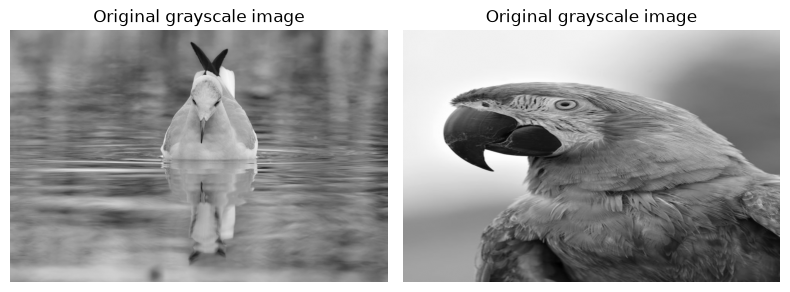

In [15]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.imshow(img1, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img2, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
added = img1 + img2
added = np.clip(added, 0, 255)
added = added.astype(np.uint8)

# opencv addition

In [17]:
img1_n = cv2.imread("sample_image.jpg", cv2.IMREAD_GRAYSCALE)
img2_n = cv2.imread("sample_color.jpg", cv2.IMREAD_GRAYSCALE)

if img1_n.shape != img2_n.shape:
    height = img1_n.shape[0]
    width = img1_n.shape[1]
    img2_n = cv2.resize(img2_n, (width, height))
    print("resized image2 to match image1 shape:", img2_n.shape)

resized image2 to match image1 shape: (853, 1280)


In [18]:
added_cv2 = cv2.add(img1_n,img2_n)
subtracted_cv2 = cv2.subtract(img1_n,img2_n)

In [19]:
averaged = (img1 + img2) / 2
averaged = averaged.astype(np.uint8)

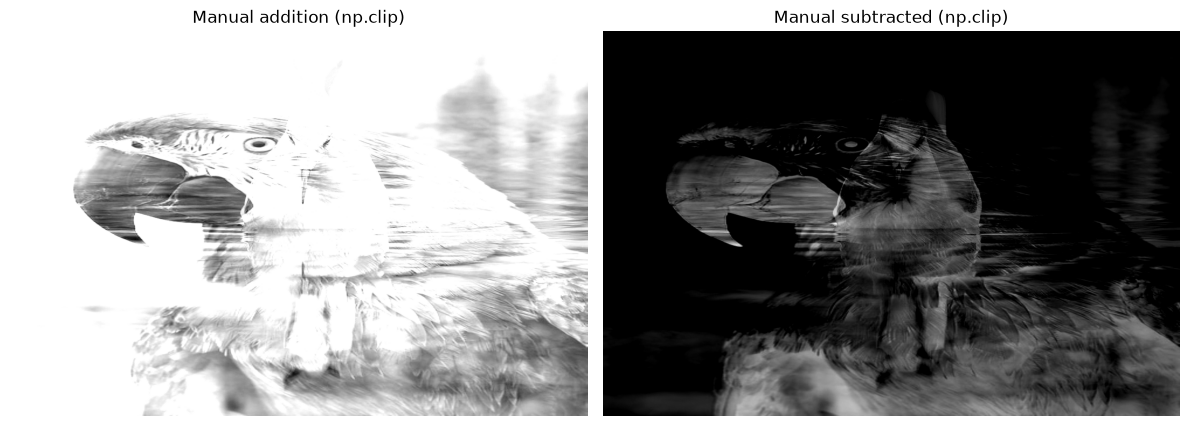

In [23]:
plt.figure(figsize=(12,8))
plt.subplot(1,2,1)
plt.imshow(added_cv2, cmap="gray")
plt.title("Manual addition (np.clip)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(subtracted_cv2, cmap="gray")
plt.title("Manual subtracted (np.clip)")
plt.axis("off")

plt.tight_layout()
plt.show()

# weighted blending (alpha blending)

In [24]:
# result = alpha * img1 + (1 - alpha) * img2

alpha = 0.7
blended = alpha * img1 + (1 - alpha) * img2
blended = np.clip(blended, 0, 255)
blended = blended.astype(np.uint8)

In [25]:
blended_cv2 = cv2.addWeighted(img1_n, alpha, img2_n, 1-alpha, 0)

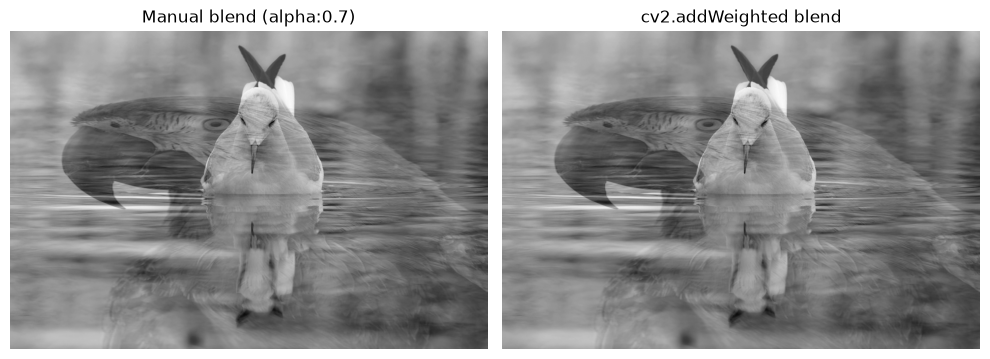

In [26]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(blended, cmap="gray")
plt.title(f"Manual blend (alpha:{alpha})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(blended_cv2, cmap="gray")
plt.title(f"cv2.addWeighted blend")
plt.axis("off")

plt.tight_layout()
plt.show()

# Masking operations

In [27]:
mask = np.zeros(img1.shape, dtype = np.uint8)
h = mask.shape[0]
w = mask.shape[1]
mask[h//4: 3*h//4, w//4: 3*w//4] = 255

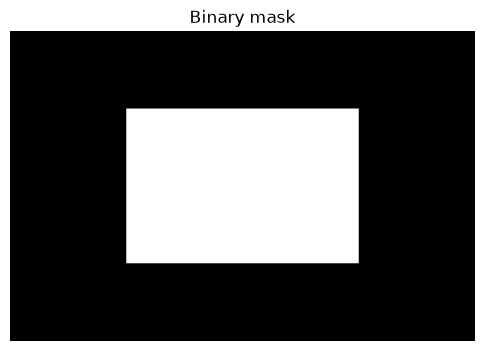

In [28]:
plt.figure(figsize=(6,5))
plt.imshow(mask, cmap='gray')
plt.title("Binary mask")
plt.axis('off')
plt.show()

In [29]:
masked_region = cv2.bitwise_and(img1_n, img1_n, mask=mask)

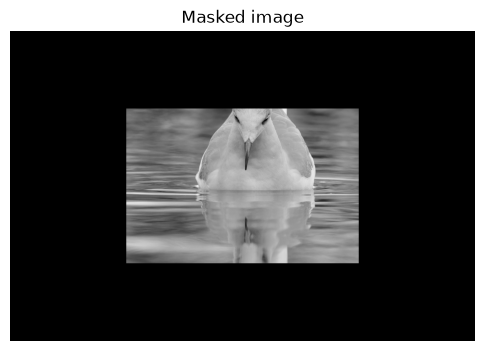

In [30]:
plt.figure(figsize=(6,5))
plt.imshow(masked_region, cmap='gray')
plt.title("Masked image")
plt.axis('off')
plt.show()

In [31]:
inverted_mask = cv2.bitwise_not(mask)
masked_region_inverse = cv2.bitwise_and(img1_n, img1_n, mask=inverted_mask)

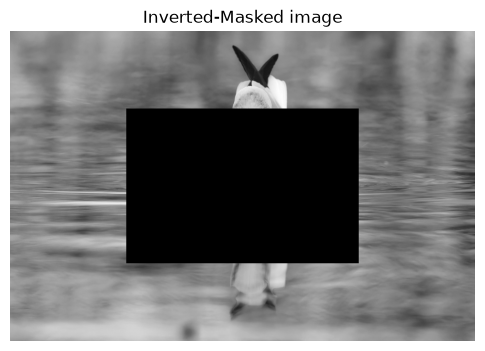

In [32]:
plt.figure(figsize=(6,5))
plt.imshow(masked_region_inverse, cmap='gray')
plt.title("Inverted-Masked image")
plt.axis('off')
plt.show()